Average Overall Rating: 3.2425
Average Effectiveness: nan
Average Satisfaction: nan


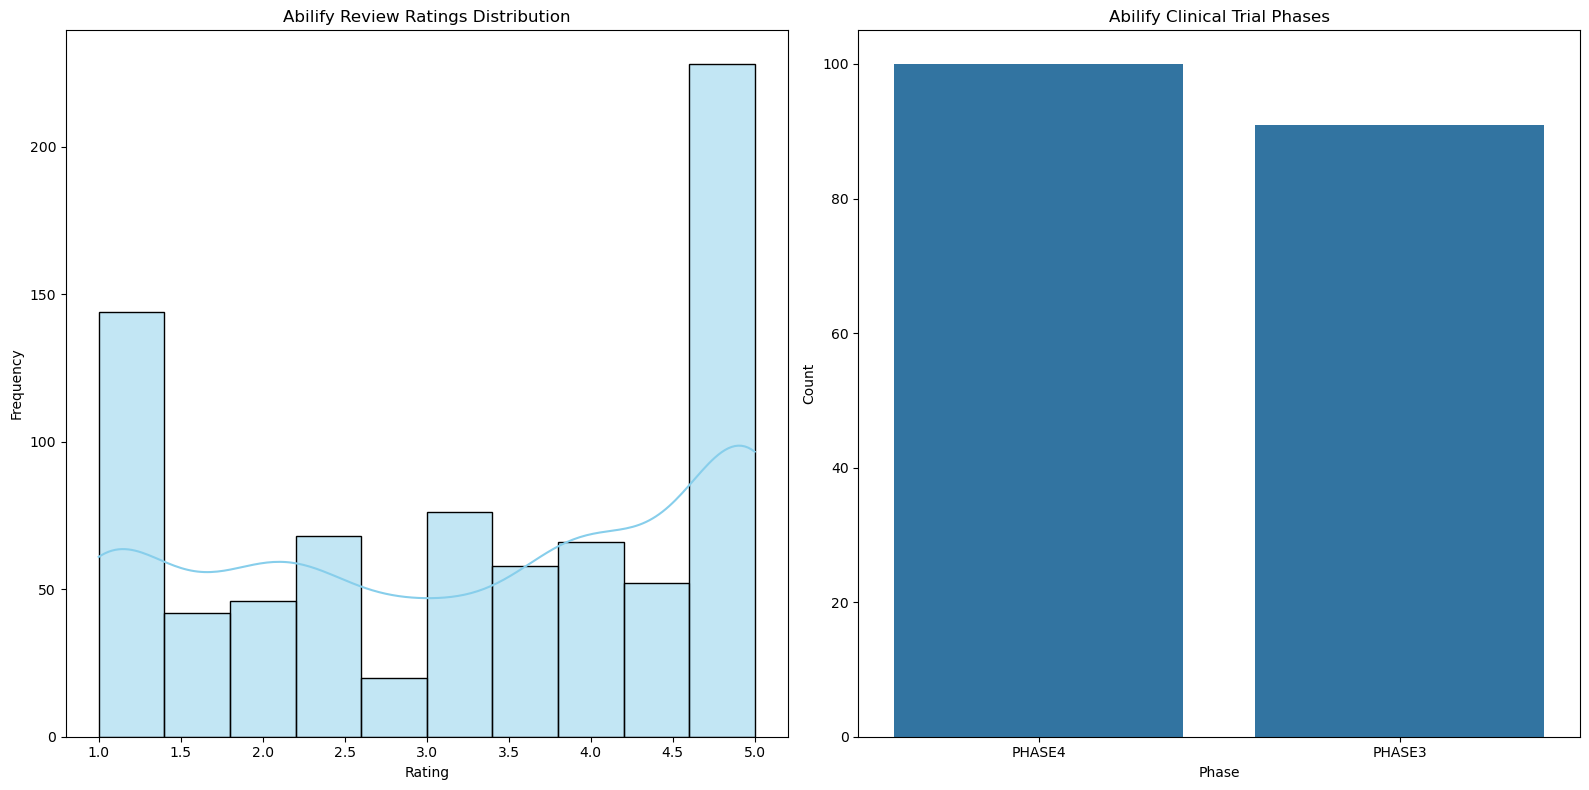


Matched Conditions in Reviews:
          Date Matched Conditions
0    7/27/2025       [Depression]
1    7/27/2025       [Depression]
2    6/19/2025                 []
3    6/19/2025                 []
4    5/16/2025       [Depression]
..         ...                ...
795   3/7/2014                 []
796   3/5/2014                 []
797   3/5/2014                 []
798   3/2/2014                 []
799   3/2/2014                 []

[800 rows x 2 columns]

Reviews with matched conditions saved to 'reviews_with_matched_conditions.csv'


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re

# Load the reviews and clinical trials data
reviews_df = pd.read_csv('abilify_oral_data.csv')
trials_df = pd.read_csv('cleaned_clinical_trials.csv')

# Clean column names by stripping any leading or trailing spaces
reviews_df.columns = reviews_df.columns.str.strip()
trials_df.columns = trials_df.columns.str.strip()

# Filter the clinical trials for 'Abilify'
trials_df = trials_df[trials_df['queriedDrug'] == 'Abilify']

# Textual comparison: Checking if conditions mentioned in reviews match the conditions from clinical trials
def compare_conditions(review_text, trial_conditions):
    matched_conditions = []
    for condition in trial_conditions:
        if condition.lower() in review_text.lower():
            matched_conditions.append(condition)
    return matched_conditions

# Loop through reviews and compare with clinical trials
matched_reviews = []
for index, review in reviews_df.iterrows():
    matched_conditions = compare_conditions(review['Textual Review'], trials_df['conditions'].dropna())
    matched_reviews.append(matched_conditions)

reviews_df['Matched Conditions'] = matched_reviews

# Calculate the effectiveness and satisfaction from reviews
def calculate_avg_rating(df, column):
    return df[column].mean() if column in df.columns else None

avg_review_rating = calculate_avg_rating(reviews_df, 'Overall Rating')
avg_effectiveness = calculate_avg_rating(reviews_df, 'Effectiveness')
avg_satisfaction = calculate_avg_rating(reviews_df, 'Satisfaction')

print(f"Average Overall Rating: {avg_review_rating}")
print(f"Average Effectiveness: {avg_effectiveness}")
print(f"Average Satisfaction: {avg_satisfaction}")

# Compare Clinical Trials: Show statistics for the clinical trial phases
trial_phases = trials_df['phases'].value_counts()

# Plotting the comparison data
fig, axes = plt.subplots(1, 2, figsize=(16, 8))

# Plot the review ratings distribution
sns.histplot(reviews_df['Overall Rating'], bins=10, kde=True, color='skyblue', ax=axes[0])
axes[0].set_title('Abilify Review Ratings Distribution')
axes[0].set_xlabel('Rating')
axes[0].set_ylabel('Frequency')

# Plot clinical trial phases
sns.barplot(x=trial_phases.index, y=trial_phases.values, ax=axes[1])
axes[1].set_title('Abilify Clinical Trial Phases')
axes[1].set_xlabel('Phase')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.show()

# Display the matched conditions between reviews and trials
print("\nMatched Conditions in Reviews:")
print(reviews_df[['Date', 'Matched Conditions']])

# You can also save this data to CSV for further processing
reviews_df.to_csv('reviews_with_matched_conditions.csv', index=False)
print("\nReviews with matched conditions saved to 'reviews_with_matched_conditions.csv'")


In [ ]:
we can seee depression is the most common condition in both reviews and clinical trials.

[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/pranayratan/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
/var/folders/j_/_3b07fdj35q3rrdgl_c7y3100000gn/T/ipykernel_33775/2061907255.py:62: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  cond_df["condition_proc"].fillna("", inplace=True)


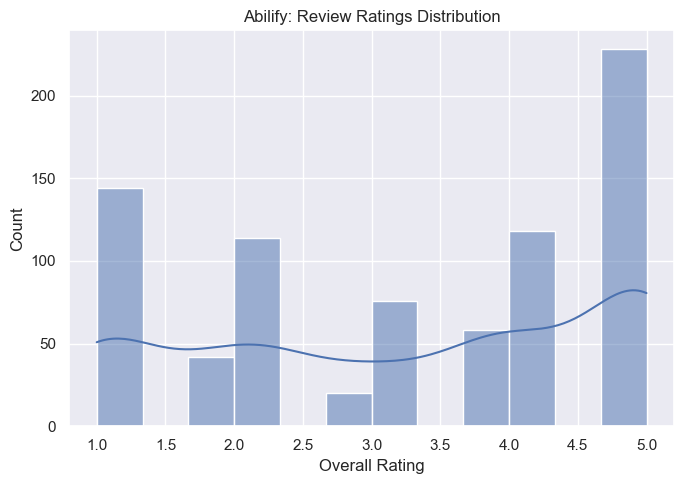

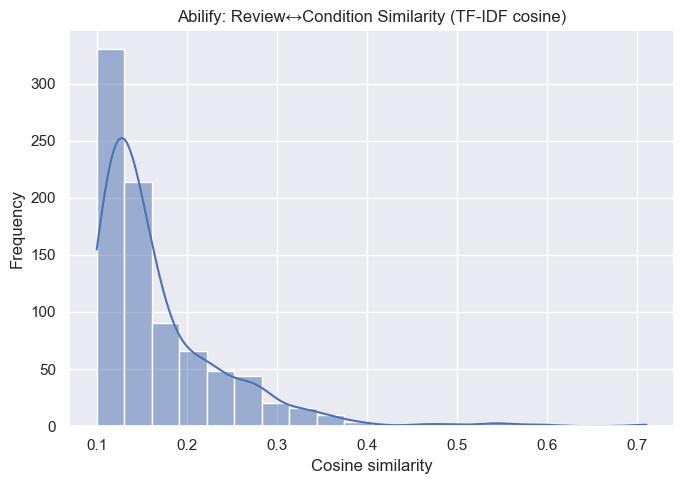

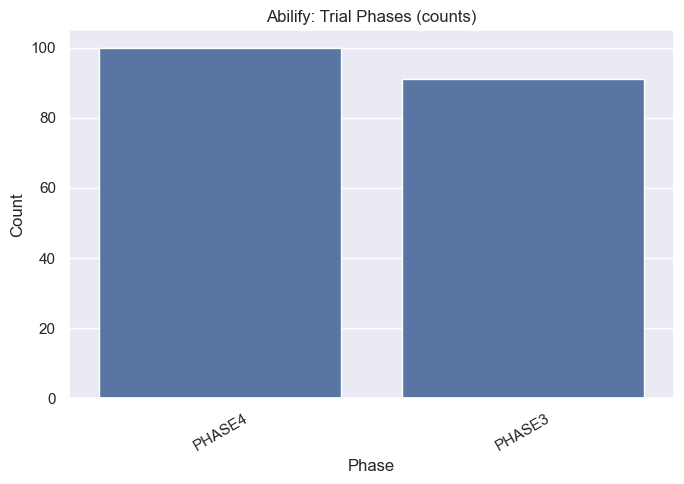


Saved: reviews_with_matched_conditions_and_similarity.csv

Sample matches:
      Date                                                   matched_conditions                                               similarity_scores
 7/27/2025 [Treatment-Refractory Depression, Postpartum Depression, Depression] [0.13445427531191978, 0.10312727735469422, 0.10312727735469422]
 7/27/2025 [Treatment-Refractory Depression, Postpartum Depression, Depression] [0.13445427531191978, 0.10312727735469422, 0.10312727735469422]
 6/19/2025                                                 [Body Weight Change]                                           [0.11345775429323902]
 6/19/2025                                                 [Body Weight Change]                                           [0.11345775429323902]
 5/16/2025                                                                   []                                                              []
 5/16/2025                                                  

In [3]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
import nltk

# Download necessary NLTK data files
nltk.download('stopwords')
from nltk.corpus import stopwords

# Simulate command-line arguments for Jupyter
class Args:
    reviews = 'abilify_oral_data.csv'
    trials = 'cleaned_clinical_trials.csv'
    drug = 'Abilify'
    topk = 3
    minsim = 0.10

args = Args()

# --------- helpers ---------

def preprocess_text(text: str) -> str:
    """Lower, keep letters/spaces, remove stopwords."""
    if pd.isna(text):
        return ""
    t = text.lower()
    t = re.sub(r"[^a-z\s]", " ", t)
    t = re.sub(r"\s+", " ", t).strip()
    if stopwords is not None:
        sw = set(stopwords.words("english"))
        t = " ".join(w for w in t.split() if w not in sw)
    return t

def split_conditions(cell: str) -> list:
    """
    Split conditions string into tokens by common separators and clean.
    e.g., "Schizophrenia; Schizoaffective Disorder" -> ["Schizophrenia", "Schizoaffective Disorder"]
    """
    if pd.isna(cell) or not str(cell).strip():
        return []
    parts = re.split(r"[;,/|]+", str(cell))
    parts = [p.strip() for p in parts if p and p.strip()]
    return parts

def build_condition_corpus(trials_for_drug: pd.DataFrame) -> pd.DataFrame:
    """
    Turn the 'conditions' column into a row-per-condition frame with both raw and processed text.
    """
    rows = []
    for _, r in trials_for_drug.iterrows():
        for cond in split_conditions(r.get("conditions", "")):
            rows.append({"condition_raw": cond, "condition_proc": preprocess_text(cond)})
    cond_df = pd.DataFrame(rows)
    if cond_df.empty:
        # ensure non-empty frame with placeholders so downstream doesn't crash
        cond_df = pd.DataFrame([{"condition_raw": "", "condition_proc": ""}])
    # drop true empties after preprocess if any
    cond_df["condition_proc"].fillna("", inplace=True)
    return cond_df.drop_duplicates().reset_index(drop=True)

# --------- main ---------

def main():
    # Load data
    reviews = pd.read_csv(args.reviews)
    trials  = pd.read_csv(args.trials)

    # Sanity: standardize column names present in your files
    required_review_cols = ["Textual Review", "Overall Rating", "Date"]
    for c in required_review_cols:
        if c not in reviews.columns:
            raise KeyError(f"Reviews CSV missing required column: {c}")

    # Trials columns you showed:
    if "queriedDrug" not in trials.columns:
        raise KeyError("Trials CSV must contain 'queriedDrug'.")
    if "conditions" not in trials.columns:
        trials["conditions"] = ""

    # Filter trials by the requested drug
    trials_d = trials[trials["queriedDrug"].astype(str).str.strip().str.lower()
                      == args.drug.lower()].copy()
    if trials_d.empty:
        warnings.warn(f"No trials found for drug '{args.drug}'. Continuing with empty trials.", RuntimeWarning)

    # Build per-condition DF
    cond_df = build_condition_corpus(trials_d)

    # Prepare reviews: we **don't** rely on a 'Drug Name' column because it isn't in your CSV.
    reviews["text_proc"] = reviews["Textual Review"].astype(str).map(preprocess_text)

    # Drop rows with truly empty processed text (no words)
    reviews = reviews[reviews["text_proc"].str.len() > 0].reset_index(drop=True)

    if reviews.empty:
        raise ValueError("After preprocessing, no non-empty review texts remain.")

    # ----- Vectorize on combined corpus to keep vocabulary consistent -----
    joint_corpus = pd.concat([reviews["text_proc"], cond_df["condition_proc"]], axis=0).tolist()

    vectorizer = TfidfVectorizer(min_df=2)  # min_df=2 to reduce noise; adjust as needed
    X = vectorizer.fit_transform(joint_corpus)

    # Split back out: first N rows are reviews; remaining are conditions
    n_reviews = reviews.shape[0]
    X_reviews   = X[:n_reviews]
    X_conditions = X[n_reviews:]

    # ----- Similarity -----
    sim = cosine_similarity(X_reviews, X_conditions)  # shape: (#reviews, #conditions)

    # Confirm shapes align with our review DF indexing:
    assert sim.shape[0] == len(reviews), "Similarity rows != # of reviews (unexpected)."

    # For each review, collect top-k condition matches above threshold
    topk = max(1, int(args.topk))
    mins = float(args.minsim)

    matched_conditions = []
    matched_scores     = []

    for i in range(len(reviews)):
        row_scores = sim[i]
        order = np.argsort(-row_scores)
        picks = []
        pscores = []

        for j in order[:topk*3]:  # check a little deeper; we'll filter by threshold
            score = float(row_scores[j])
            if score >= mins:
                cond_text = cond_df.iloc[j]["condition_raw"]
                picks.append(cond_text)
                pscores.append(score)
                if len(picks) >= topk:
                    break

        matched_conditions.append(picks)
        matched_scores.append(pscores)

    # Attach to frame (lengths match exactly; no broadcast issues)
    reviews = reviews.assign(
        matched_conditions=matched_conditions,
        similarity_scores=matched_scores
    )

    # ----- Visuals -----
    sns.set_theme()

    # 1) Ratings distribution
    if reviews["Overall Rating"].notna().sum() > 0:
        plt.figure(figsize=(7,5))
        sns.histplot(reviews["Overall Rating"].dropna(), bins=12, kde=True)
        plt.title(f"{args.drug}: Review Ratings Distribution")
        plt.xlabel("Overall Rating")
        plt.ylabel("Count")
        plt.tight_layout()
        plt.show()

    # 2) Similarity score distribution
    flat_scores = [s for sub in matched_scores for s in sub]
    if len(flat_scores) > 0:
        plt.figure(figsize=(7,5))
        sns.histplot(flat_scores, bins=20, kde=True)
        plt.title(f"{args.drug}: Review↔Condition Similarity (TF-IDF cosine)")
        plt.xlabel("Cosine similarity")
        plt.ylabel("Frequency")
        plt.tight_layout()
        plt.show()

    # 3) Trial phases bar chart
    if "phases" in trials_d.columns and trials_d["phases"].notna().any():
        phases_counts = trials_d["phases"].value_counts()
        if len(phases_counts):
            plt.figure(figsize=(7,5))
            sns.barplot(x=phases_counts.index, y=phases_counts.values)
            plt.title(f"{args.drug}: Trial Phases (counts)")
            plt.xlabel("Phase")
            plt.ylabel("Count")
            plt.xticks(rotation=30)
            plt.tight_layout()
            plt.show()

    # ----- Save results -----
    out_csv = "reviews_with_matched_conditions_and_similarity.csv"
    reviews[["Date", "Overall Rating", "Textual Review", "matched_conditions", "similarity_scores"]].to_csv(out_csv, index=False)
    print(f"\nSaved: {out_csv}")

    # also print a quick sample of matches
    print("\nSample matches:")
    print(reviews[["Date", "matched_conditions", "similarity_scores"]].head(10).to_string(index=False))


if __name__ == "__main__":
    main()
